# Multivariate Log-Normal Distribution

`MultivariateLogNormal(mean, cov)` is the multivariate generalization of the log-normal: the elementwise exponential of a `MultivariateNormal`. If `Y` is multivariate normal, then `X = exp(Y)` (component by component) is multivariate log-normal.

In [1]:
from symbulate import *

## Draw a value

Each draw is a vector of positive values.

In [2]:
MultivariateLogNormal(mean=[0, 0], cov=[[1, 0.5], [0.5, 1]]).draw()

(6.265834649240881, 1.143409480280614)

## Simulate

Every simulated value is a vector of positive, correlated values.

In [3]:
MultivariateLogNormal(mean=[0, 0], cov=[[1, 0.5], [0.5, 1]]).sim(1000)

0,"(0.9047571282488417, 0.5107281556388484)"
1,"(0.6315880513413902, 0.7053157730002096)"
2,"(1.4664341897917765, 0.5870550444725904)"
3,"(3.679233405524642, 1.4112517021975284)"
4,"(3.357619169632444, 2.0559238270184967)"
5,"(2.2664604135039452, 3.0730971741605204)"
6,"(0.6847162469055246, 1.3741280888366139)"
7,"(0.18079264430773317, 0.7145441437469865)"
8,"(1.3840911035362304, 2.4576394980930214)"
...,...
999,"(0.8525965096021979, 0.8887341583131433)"


## Mean, variance, and standard deviation

Each component's mean is `exp(mean_i + cov_ii / 2)`.

In [4]:
X = MultivariateLogNormal(mean=[0, 0], cov=[[1, 0.5], [0.5, 1]])
X.mean(), X.var(), X.sd()

((1.6487212707001282, 1.6487212707001282),
 (4.670774270471604, 4.670774270471604),
 (2.1611974158950877, 2.1611974158950877))

## Covariance matrix

`cov()` applies the standard log-normal transform to the underlying covariance: entry `(i, j)` is `exp(mean_i + mean_j + (cov_ii + cov_jj)/2) * (exp(cov_ij) - 1)`. A positive underlying correlation stays positive here.

In [5]:
X.cov()

array([[4.67077427, 1.76340724],
       [1.76340724, 4.67077427]])

## Correlation matrix

`corr()` rescales the covariance into correlations between -1 and 1.

In [6]:
X.corr()

array([[1.        , 0.37754067],
       [0.37754067, 1.        ]])

## Evaluate the pdf at a point

The density is defined on the positive orthant (every coordinate must be greater than 0).

In [7]:
MultivariateLogNormal(mean=[0, 0], cov=[[1, 0.5], [0.5, 1]]).pdf([1, 1])

np.float64(0.1837762984739307)

## Plot the joint distribution

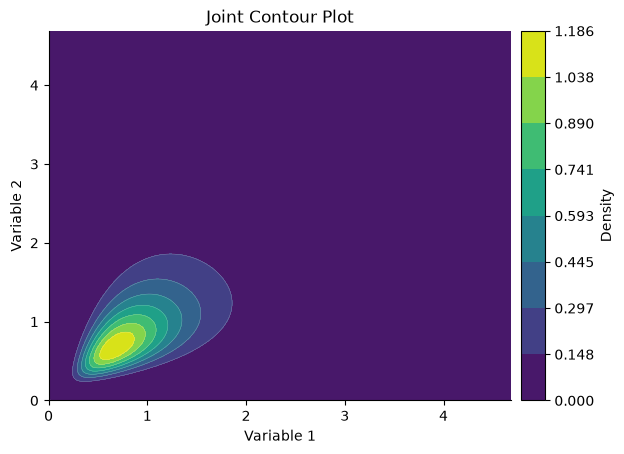

In [8]:
MultivariateLogNormal(mean=[0, 0], cov=[[0.25, 0.15], [0.15, 0.25]]).plot()

### Contour lines instead of a smooth surface

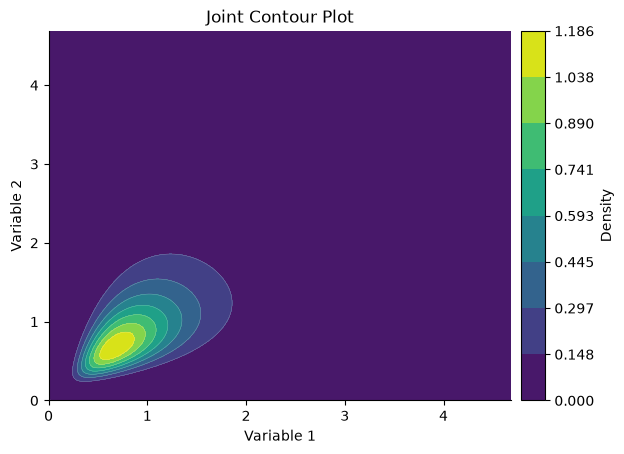

In [9]:
MultivariateLogNormal(
    mean=[0, 0], cov=[[0.25, 0.15], [0.15, 0.25]]
).plot(contour=True)

## More than two variables: pick a pair with `dims`

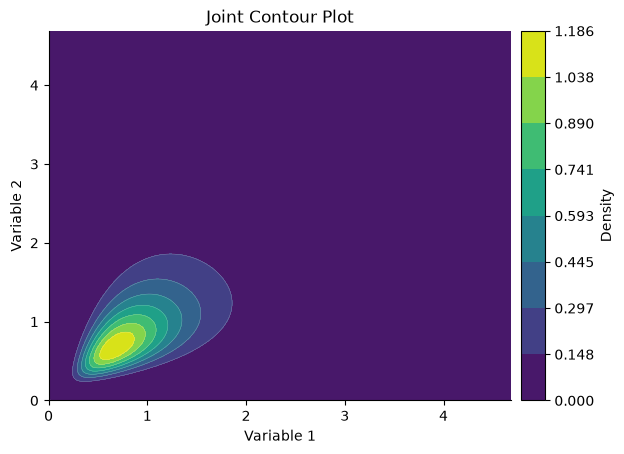

In [10]:
Z = MultivariateLogNormal(
    mean=[0, 0, 0],
    cov=[[0.25, 0.15, 0.0], [0.15, 0.25, 0.0], [0.0, 0.0, 0.25]],
)
Z.plot(variables=(0, 1))

Variables 0 and 2 have zero covariance, so that pair has no tilt.

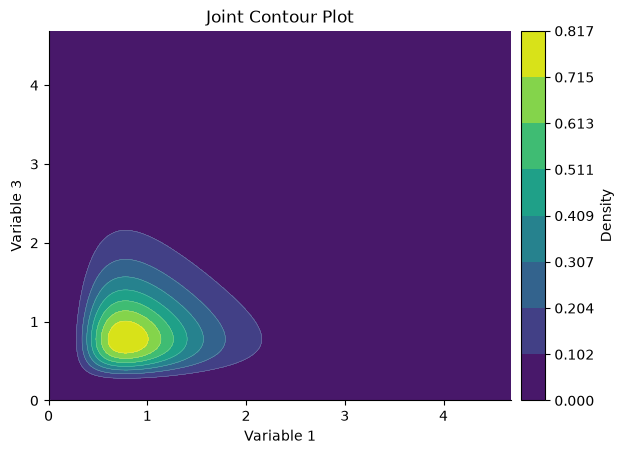

In [11]:
Z.plot(variables=(0, 2))

## Every pair at once (the default)

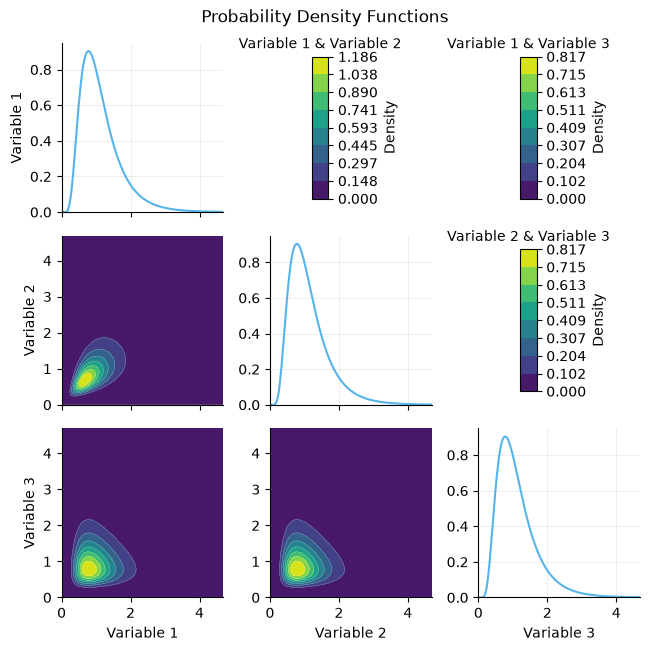

In [12]:
Z.plot()